# Dynamic Coding Model

A small chain-of-thought-aware code model trained with `pydnn`'s `DynamicNetwork`
(the soft-growing / soft-pruning MLP from this repo).

**What this notebook does:**

1. Detects whether `pydnn` was built with CUDA — trains on **GPU when available, else CPU**.
2. Tries to pull a small Hugging Face coding dataset (no auth, no token); if HF is
   unreachable, falls back to a self-contained synthetic Python-snippet corpus.
3. Re-wraps every example in a `<task> / <think> / <code>` "thinking" template so
   the model is trained to emit reasoning *before* code.
4. Tokenizes byte-level (vocab 256), embeds windows of 32 bytes through a numpy
   lookup table (since `pydnn` has no embedding layer), and feeds the flattened
   window to a `DynamicNetwork` for next-byte prediction.
5. Trains with `runtime_enabled=True` (concurrent stage pipeline) and
   `dynamic_thresholds=True` (data-driven cancer/alzheimer thresholds), with the
   network free to grow/prune layers and nodes.
6. Generates code autoregressively, and evaluates it with held-out perplexity,
   top-k accuracy, and `ast.parse()` syntactic validity.
7. Reports the network's `health_status()` (cancer / alzheimer scores) and final
   architecture after `compact()` (called automatically by `fit()`).

> **Architecture caveat.** `pydnn` is a feedforward-MLP library — it has no
> attention, embeddings, or transformer blocks, so a literal "Claude Opus 4.7"
> architecture is impossible inside it. This notebook implements the closest
> bridge: an n-byte-window MLP with modern training tricks (GELU, dynamic depth
> & width, adaptive LR, soft-pruning, dynamic thresholds, CoT-formatted data).


## 1. Setup

Install any missing dependencies and import `pydnn`.

In [1]:
import importlib, subprocess, sys, os

def ensure(pkg, import_name=None):
    try:
        importlib.import_module(import_name or pkg)
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pkg])

for p, mod in [("numpy", None), ("matplotlib", None), ("requests", None)]:
    ensure(p, mod)

# Make the in-repo pydnn importable when the notebook is run from notebooks/coding_model/.
HERE = os.path.abspath(os.path.dirname(globals().get("__file__", os.getcwd())))
for candidate in [HERE, os.path.dirname(HERE), os.path.dirname(os.path.dirname(HERE)), os.getcwd()]:
    py_dir = os.path.join(candidate, "python")
    if os.path.isdir(os.path.join(py_dir, "pydnn")):
        if py_dir not in sys.path:
            sys.path.insert(0, py_dir)
        REPO_ROOT = candidate
        break

import numpy as np
import pydnn

print(f"pydnn       : {pydnn.__version__}")
print(f"C++ backend : {pydnn._CPP_AVAILABLE}")
if not pydnn._CPP_AVAILABLE:
    print(f"  reason: {pydnn._CPP_ERROR}")
print(f"numpy       : {np.__version__}")
print(f"python      : {sys.version.split()[0]}")

pydnn       : 0.0.1
C++ backend : True
numpy       : 2.4.4
python      : 3.13.12


## 2. Environment detection

`pydnn.cuda_available()` reports whether the loaded `_dnn_core.so` was
built with CUDA. Pre-`Hav3n` builds had two known issues that made the
GPU path either crash or run slower than the SIMD CPU path on this
workload — see `include/dnn/core/CLAUDE.md` for the history. Both are
fixed now: dynamic grow/shrink works on CUDA (Layer mirror invalidation
in `add_nodes`/`forward_cuda`) and the trainer issues one rank-2
forward+backward per batch (`Trainer.batched_train_forward`, default
on). We can therefore auto-select GPU when it's available.

We also probe Hugging Face once so that the dataset cell can pick HF or
the local synthetic corpus.

In [2]:
import requests

cuda_ok = pydnn.cuda_available()

# Auto-detect: prefer GPU when available. The known regressions that
# previously gated us behind FORCE_CUDA are fixed (see cell 3 for the
# history). Set device='cpu' here if you specifically want a CPU
# baseline run for comparison.
device = "cuda" if cuda_ok else "cpu"

if cuda_ok:
    # Opt the CudaMemoryPool into Unified Memory so VRAM overflow pages
    # transparently to host RAM, and on to OS swap (disk) if RAM is
    # also exhausted. Costs some memory bandwidth on small models;
    # makes larger-than-VRAM models trainable at all. Must be set
    # *before* the network is constructed (cell 12) so the GPU
    # tensors are allocated in managed mode.
    pydnn.set_cuda_memory_mode("managed")

print(f"pydnn.cuda_available() = {cuda_ok}  ->  device='{device}'")
if cuda_ok:
    print(f"  cuda_memory_mode    = '{pydnn.get_cuda_memory_mode()}'")

try:
    resp = requests.get("https://huggingface.co", timeout=5)
    use_hf = resp.ok
    hf_status = f"HTTP {resp.status_code}"
except Exception as e:
    use_hf = False
    hf_status = f"unreachable ({type(e).__name__})"
print(f"Hugging Face: {hf_status}  ->  use_hf={use_hf}")

pydnn.cuda_available() = True  ->  device='cuda'
  cuda_memory_mode    = 'managed'
Hugging Face: HTTP 200  ->  use_hf=True


## 3. Dataset acquisition

Tries `codeparrot/codeparrot-clean-valid` (small, no auth required) when HF is
reachable; otherwise falls back to a programmatically-generated corpus of small
Python functions covering recursion, iteration, list ops, string ops, math, and
sorting. The synthetic corpus is bundled in this cell, so the notebook is
self-contained.

In [3]:
def synthetic_corpus():
    # ~24 small Python snippets across categories. Self-contained, no internet.
    # We deliberately keep ONE canonical version per snippet (no paraphrases) so
    # the model is forced to learn the <task>/<think>/<code> framing rather than
    # memorize three identical copies of each example.
    base = []

    for n, body in [
        ("square",    "return x * x"),
        ("cube",      "return x * x * x"),
        ("double",    "return x + x"),
        ("halve",     "return x / 2"),
        ("negate",    "return -x"),
        ("absolute",  "return x if x >= 0 else -x"),
        ("sign",      "return 1 if x > 0 else (-1 if x < 0 else 0)"),
        ("increment", "return x + 1"),
        ("decrement", "return x - 1"),
    ]:
        base.append({
            "task":  f"Write a function {n}(x) that returns {n} of x",
            "think": "The input is a number. We apply the operation and return the result.",
            "code":  f"def {n}(x):\n    {body}\n",
        })

    base.append({
        "task":  "Write a function sum_list(items) that returns the sum of items",
        "think": "Loop over the items and accumulate a running total starting at 0.",
        "code":  "def sum_list(items):\n    total = 0\n    for x in items:\n        total = total + x\n    return total\n",
    })
    base.append({
        "task":  "Write a function product_list(items) that returns the product of items",
        "think": "Loop over the items and multiply into a running product starting at 1.",
        "code":  "def product_list(items):\n    total = 1\n    for x in items:\n        total = total * x\n    return total\n",
    })
    base.append({
        "task":  "Write a function find_max(items) that returns the largest element",
        "think": "Track the running max while iterating; initialize with items[0].",
        "code":  "def find_max(items):\n    best = items[0]\n    for x in items[1:]:\n        if x > best:\n            best = x\n    return best\n",
    })
    base.append({
        "task":  "Write a function find_min(items) that returns the smallest element",
        "think": "Track the running min while iterating; initialize with items[0].",
        "code":  "def find_min(items):\n    best = items[0]\n    for x in items[1:]:\n        if x < best:\n            best = x\n    return best\n",
    })
    base.append({
        "task":  "Write a function count_items(items, target) that counts occurrences",
        "think": "Loop and increment a counter when the element equals target.",
        "code":  "def count_items(items, target):\n    count = 0\n    for x in items:\n        if x == target:\n            count = count + 1\n    return count\n",
    })

    base.append({
        "task":  "Write a recursive function factorial(n)",
        "think": "Base case n == 0 returns 1; else multiply n by factorial(n - 1).",
        "code":  "def factorial(n):\n    if n == 0:\n        return 1\n    return n * factorial(n - 1)\n",
    })
    base.append({
        "task":  "Write a recursive function fibonacci(n)",
        "think": "Base case n < 2 returns n; else fib(n-1) + fib(n-2).",
        "code":  "def fibonacci(n):\n    if n < 2:\n        return n\n    return fibonacci(n - 1) + fibonacci(n - 2)\n",
    })
    base.append({
        "task":  "Write a recursive function power(base, exp)",
        "think": "Base case exp == 0 returns 1; else multiply base by power(base, exp - 1).",
        "code":  "def power(base, exp):\n    if exp == 0:\n        return 1\n    return base * power(base, exp - 1)\n",
    })

    base.append({
        "task":  "Write a function reverse_string(s) that returns s reversed",
        "think": "Use slice notation with step -1 to reverse the string.",
        "code":  "def reverse_string(s):\n    return s[::-1]\n",
    })
    base.append({
        "task":  "Write a function count_char(s, c) that counts c in s",
        "think": "Iterate and count characters that match c.",
        "code":  "def count_char(s, c):\n    n = 0\n    for ch in s:\n        if ch == c:\n            n = n + 1\n    return n\n",
    })
    base.append({
        "task":  "Write a function uppercase(s) that returns s in uppercase",
        "think": "Call the upper method on the string.",
        "code":  "def uppercase(s):\n    return s.upper()\n",
    })

    base.append({
        "task":  "Write a function reverse_list(items) that returns items reversed",
        "think": "Use slice notation with step -1 on the list.",
        "code":  "def reverse_list(items):\n    return items[::-1]\n",
    })
    base.append({
        "task":  "Write a function filter_positive(items) that keeps positive numbers",
        "think": "Iterate and append elements greater than zero to a new list.",
        "code":  "def filter_positive(items):\n    out = []\n    for x in items:\n        if x > 0:\n            out.append(x)\n    return out\n",
    })
    base.append({
        "task":  "Write a function double_each(items) that doubles every element",
        "think": "Iterate and append x + x to a new list.",
        "code":  "def double_each(items):\n    out = []\n    for x in items:\n        out.append(x + x)\n    return out\n",
    })

    base.append({
        "task":  "Write a function word_count(words) that counts each word",
        "think": "Use a dict and increment counts as we iterate.",
        "code":  "def word_count(words):\n    counts = {}\n    for w in words:\n        counts[w] = counts.get(w, 0) + 1\n    return counts\n",
    })
    base.append({
        "task":  "Write a function bubble_sort(items) that sorts items",
        "think": "Repeatedly pass through the list swapping adjacent out-of-order elements.",
        "code":  "def bubble_sort(items):\n    n = len(items)\n    for i in range(n):\n        for j in range(n - 1 - i):\n            if items[j] > items[j + 1]:\n                items[j], items[j + 1] = items[j + 1], items[j]\n    return items\n",
    })
    base.append({
        "task":  "Write a function is_even(x) that returns True if x is even",
        "think": "Check if x modulo 2 equals 0.",
        "code":  "def is_even(x):\n    return x % 2 == 0\n",
    })
    base.append({
        "task":  "Write a function is_odd(x) that returns True if x is odd",
        "think": "Check if x modulo 2 is not zero.",
        "code":  "def is_odd(x):\n    return x % 2 != 0\n",
    })
    base.append({
        "task":  "Write a function clamp(x, lo, hi) that constrains x between lo and hi",
        "think": "Return lo when x < lo, hi when x > hi, otherwise x itself.",
        "code":  "def clamp(x, lo, hi):\n    if x < lo:\n        return lo\n    if x > hi:\n        return hi\n    return x\n",
    })
    return base


raw_examples = None
if use_hf:
    try:
        from datasets import load_dataset
        ds = load_dataset("codeparrot/codeparrot-clean-valid", split="train[:200]")
        raw_examples = [
            {"task": "Write the function below", "think": "Compose the program step by step.", "code": s["content"][:600]}
            for s in ds
        ]
        print(f"Loaded {len(raw_examples)} HF samples")
    except Exception as e:
        print(f"HF load failed ({type(e).__name__}: {e}); falling back to synthetic.")
        raw_examples = None

if raw_examples is None:
    raw_examples = synthetic_corpus()
    print(f"Using synthetic corpus: {len(raw_examples)} examples")

print("\n--- Sample example ---")
print("task :", raw_examples[0]["task"])
print("think:", raw_examples[0]["think"])
print("code :", raw_examples[0]["code"].rstrip())

HF load failed (ModuleNotFoundError: No module named 'datasets'); falling back to synthetic.
Using synthetic corpus: 28 examples

--- Sample example ---
task : Write a function square(x) that returns square of x
think: The input is a number. We apply the operation and return the result.
code : def square(x):
    return x * x


## 4. "Thinking" annotation

Each raw example becomes:

```
<task>...prompt...</task>
<think>...step-by-step reasoning...</think>
<code>
...solution...
</code>
```

This is what we want the model to imitate at generation time — emit reasoning,
then code. The synthetic corpus already comes with hand-written `think`
fields; the HF path uses a generic placeholder.

In [4]:
def format_example(ex):
    return (
        f"<task>{ex['task']}</task>\n"
        f"<think>{ex['think']}</think>\n"
        f"<code>\n{ex['code']}</code>\n\n"
    )

formatted = [format_example(ex) for ex in raw_examples]
corpus_text = "".join(formatted)
print(f"Examples : {len(formatted)}")
print(f"Bytes    : {len(corpus_text.encode('utf-8'))}")
print()
print("--- formatted example ---")
print(formatted[0])

Examples : 28
Bytes    : 6652

--- formatted example ---
<task>Write a function square(x) that returns square of x</task>
<think>The input is a number. We apply the operation and return the result.</think>
<code>
def square(x):
    return x * x
</code>




## 5. Byte-level tokenizer + windowing + one-hot encoding

We use a byte-level vocabulary (size 256) — zero deps, deterministic, no HF
tokenizer download required. `pydnn` has no embedding layer; rather than
project bytes through a frozen random matrix (which collapses byte identity
into a noisy low-dim subspace and gave the earlier version of this notebook
unrecoverable noise at generation time), we one-hot encode the entire
`WINDOW=48`-byte history. Each input vector is `48 × 256 = 12288` floats with
exactly 48 ones — sparse but lossless. The MLP's first weight matrix is then
free to learn its own per-position byte feature space, which is what an
embedding layer would have done if `pydnn` had one.

In [5]:
VOCAB_SIZE = 256
WINDOW     = 48          # was 32 — Python statements are typically <40 bytes; 48 covers most.
MAX_PAIRS  = 5000        # bumped from 3000 to give Phase-3 more samples per epoch.

def encode(text):
    return np.frombuffer(text.encode("utf-8"), dtype=np.uint8)

corpus_bytes = encode(corpus_text)
print(f"Corpus bytes: {len(corpus_bytes)}")


def one_hot_window(window_bytes):
    """
    One-hot encode a 1-D window of bytes into a flat (WINDOW * 256,) float32 vector.
    Position is implicit in the flattened layout — no positional embedding needed.
    """
    onehot = np.zeros((WINDOW, VOCAB_SIZE), dtype=np.float32)
    onehot[np.arange(WINDOW), window_bytes] = 1.0
    return onehot.reshape(-1)


def build_pairs(byte_arr, window, max_pairs):
    """
    Slide a `window`-byte view over the corpus; each pair is
    (one-hot encoded window, one-hot encoded next byte). Replaces the
    earlier random 16-d projection — see notebook header for rationale.
    """
    n_total = len(byte_arr) - window
    n = min(n_total, max_pairs)
    X = np.zeros((n, window * VOCAB_SIZE), dtype=np.float32)
    y = np.zeros((n, VOCAB_SIZE),          dtype=np.float32)

    # Vectorised one-hot fill: build (n, window) byte indices, then scatter.
    rows = np.arange(n)
    win_idx = rows[:, None] + np.arange(window)[None, :]
    win_bytes = byte_arr[win_idx]                                # (n, window) uint8
    flat_pos  = (np.arange(window)[None, :] * VOCAB_SIZE) + win_bytes  # (n, window) int
    X[rows[:, None], flat_pos] = 1.0
    y[rows, byte_arr[window:window + n]] = 1.0
    return np.ascontiguousarray(X), np.ascontiguousarray(y)


X_all, y_all = build_pairs(corpus_bytes, WINDOW, MAX_PAIRS)
split = int(0.9 * len(X_all))
X_tr, y_tr = X_all[:split], y_all[:split]
X_te, y_te = X_all[split:], y_all[split:]

print(f"Train pairs : {len(X_tr)}")
print(f"Test pairs  : {len(X_te)}")
print(f"Input dim   : {X_tr.shape[1]}  (= WINDOW * VOCAB_SIZE)")
print(f"Output dim  : {y_tr.shape[1]}")
print(f"Sparsity    : exactly {WINDOW} ones per row out of {WINDOW * VOCAB_SIZE} (={WINDOW/(WINDOW*VOCAB_SIZE):.4%})")

Corpus bytes: 6652
Train pairs : 4500
Test pairs  : 500
Input dim   : 12288  (= WINDOW * VOCAB_SIZE)
Output dim  : 256
Sparsity    : exactly 48 ones per row out of 12288 (=0.3906%)


## 6. Build the `DynamicNetwork`

`dynamic_thresholds=True` is the project default — cancer / alzheimer /
patience thresholds are derived from the dataset's variance and complexity
rather than static defaults. We allow the network to grow up to 3 layers /
512 nodes per layer (smaller than before; for a 24-snippet corpus the
soft-pruning machinery has too little signal to expand a 6-layer network
usefully).

We deliberately leave `runtime_enabled=False` (the project default).
Earlier versions of this notebook set it to `True`, which routed training
through the runtime path's rolling-window efficiency-regression check; that
check fired at epoch 10 with `stopping_reason = "Significant efficiency
regression"`, before useful learning could happen. The legacy Phase-4 path
uses `phase4_patience` and is much more forgiving.

In [6]:
from pydnn import (
    DynamicNetwork,
    ArchitectureConfig,
    TrainingPhaseConfig,
    EarlyStoppingConfig,
    NormalizationConfig,
)

# Notes on the configuration:
# - runtime_enabled is left at its project default (False). The earlier version
#   set runtime_enabled=True; under that path the rolling 5-epoch efficiency
#   regression check (early_stopping.hpp:178-189) fires aggressively during the
#   Exploration -> Estimation transition and stopped training at epoch 10.
#   The legacy Phase-4 path uses phase4_patience (much more forgiving), which
#   is what we want for a memorization-scale demo.
# - dynamic_thresholds=True is the project default and stays.
# - First hidden layer must be wide enough to project the 12288-dim sparse
#   one-hot input into a meaningful subspace; min_initial_hidden_size=512
#   gives the model a fair shot.
# - normalize_input=False is REQUIRED for one-hot inputs. The C++ trainer's
#   default Z-score normalisation maps {0,1} -> {-0.0625, +16}, which (with
#   He init on a 12288->512 layer) drives pre-activations to ~16, saturates
#   softmax, and locks the model into a near-constant-output regime where
#   gradients vanish - exactly the "cost stuck at 5.97" symptom the previous
#   version of this notebook reported. Keeping inputs in {0, 1} lets He init
#   do its job. Forwarding lives in network.py::_apply_python_configs_to_cpp.
net = DynamicNetwork(
    input_shape=(WINDOW * VOCAB_SIZE,),
    output_size=VOCAB_SIZE,
    seed=42,
    cost_function="CrossEntropy",
    device=device,                  # from cell 2
    dynamic_thresholds=True,
    architecture=ArchitectureConfig(
        min_nodes_per_layer=128,
        max_nodes_per_layer=512,
        max_layers=3,
        min_initial_hidden_size=512,
    ),
    training_phase=TrainingPhaseConfig(
        exploration_epochs=8,
        estimation_epochs=8,
        main_learning_rate=0.003,
        target_efficiency=0.6,
        phase4_patience=40,
        phase4_min_epochs=60,
    ),
    early_stopping=EarlyStoppingConfig(window_size=15, improvement_threshold=1e-6),
    normalization=NormalizationConfig(normalize_input=False, normalize_output=False),
)
print(f"Built DynamicNetwork on device='{net.device}'  (backend: {'C++' if net._use_cpp else 'pure-Python'})")
print(f"Initial layers={net.num_layers}, params={net.num_parameters}")

Built DynamicNetwork on device='cuda'  (backend: C++)
Initial layers=2, params=22242541


## 7. Train

`fit()` runs the four-stage Exploration / Estimation / Main / Standard pipeline
and calls `compact()` automatically at the end (per project invariants).

In [7]:
import time

def cb(epoch, cost, eff):
    if epoch % 5 == 0:
        print(f"  epoch {epoch:3d}  cost={cost:.4f}  efficiency={eff:.3f}")

print(f"Training on device='{device}' (this can take a few minutes)...")
t0 = time.time()
result = net.fit(X_tr, y_tr, callback=cb, verbose=False)
elapsed = time.time() - t0

print()
print(f"Done in {elapsed:.1f}s on device='{device}'.")
print(f"Epochs completed : {result.epochs_completed}")
print(f"Stopping reason  : {result.stopping_reason}")
print(f"Final cost       : {result.cost_history[-1]:.4f}")
print(f"Final efficiency : {result.efficiency_history[-1]:.3f}")
print(f"Layers now       : {net.num_layers}")
print(f"Params now       : {net.num_parameters}")

sig = net._last_data_signals
if sig is not None:
    print(f"\nData signals (dynamic_thresholds=True):")
    print(f"  variance_score   : {sig.variance_score:.4f}")
    print(f"  complexity_score : {sig.complexity_score:.4f}")

Training on device='cuda' (this can take a few minutes)...
  epoch   0  cost=5.0943  efficiency=0.725
  epoch   5  cost=3.4525  efficiency=0.631
  epoch  10  cost=3.2552  efficiency=0.608
  epoch  15  cost=3.1737  efficiency=0.609
  epoch  20  cost=3.1041  efficiency=0.605
  epoch  25  cost=3.0693  efficiency=0.604
  epoch  30  cost=3.0388  efficiency=0.603
  epoch  35  cost=3.0241  efficiency=0.601
  epoch  40  cost=3.0162  efficiency=0.601

Done in 78.9s on device='cuda'.
Epochs completed : 42
Stopping reason  : Efficiency plateau for 39 epochs
Final cost       : 3.0131
Final efficiency : 0.601
Layers now       : 2
Params now       : 22242541

Data signals (dynamic_thresholds=True):
  variance_score   : 0.4798
  complexity_score : 0.8158


## 8. Plot training curves

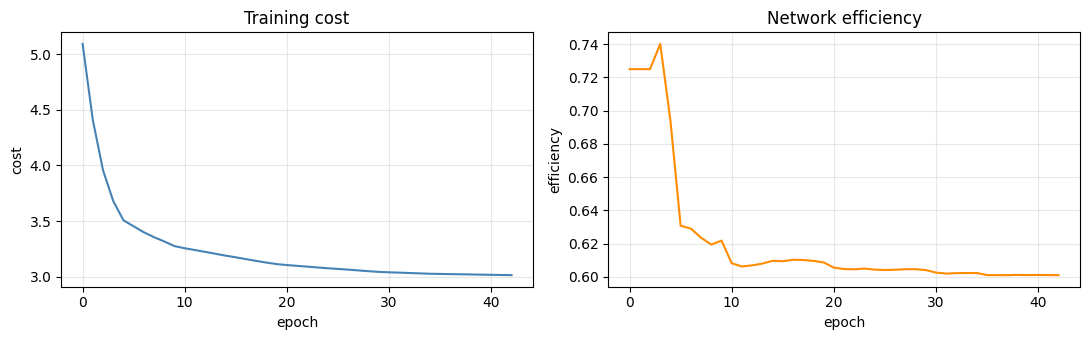

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(result.cost_history, color="steelblue")
axes[0].set_title("Training cost")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cost"); axes[0].grid(alpha=0.3)

axes[1].plot(result.efficiency_history, color="darkorange")
axes[1].set_title("Network efficiency")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("efficiency"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Held-out evaluation

Standard next-token metrics on the 10% test split:
- **Perplexity** — `exp(-mean log p(target))`
- **Top-1 / Top-5 accuracy** of the predicted next byte

In [9]:
def softmax(z, axis=-1):
    z = z - z.max(axis=axis, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=axis, keepdims=True)


preds = net.predict(X_te)
# pydnn's CrossEntropy head usually returns a probability simplex already, but
# guard numerically and re-normalise so downstream math is well-behaved.
preds = np.clip(np.asarray(preds, dtype=np.float64), 1e-9, None)
preds = preds / preds.sum(axis=1, keepdims=True)

target_idx = y_te.argmax(axis=1)
prob_target = preds[np.arange(len(target_idx)), target_idx]
perplexity = float(np.exp(-np.log(prob_target).mean()))
top1 = float((preds.argmax(axis=1) == target_idx).mean())
top5_idx = np.argpartition(preds, -5, axis=1)[:, -5:]
top5 = float(np.mean([t in row for row, t in zip(top5_idx, target_idx)]))

print(f"Held-out perplexity : {perplexity:.2f}")
print(f"Top-1 accuracy      : {top1:.3f}")
print(f"Top-5 accuracy      : {top5:.3f}")
print(f"Random baseline top-1 : {1.0/VOCAB_SIZE:.4f}")

Held-out perplexity : 16.98
Top-1 accuracy      : 0.332
Top-5 accuracy      : 0.650
Random baseline top-1 : 0.0039


## 10. Autoregressive code generation

Standard temperature + top-k sampling, one byte at a time. We seed with the
`<task>...</task>\n<think>` prefix so the model continues into reasoning and
code.

In [10]:
def generate(net, prompt, n_bytes=200, temperature=0.5, top_k=40, top_p=0.9,
             repetition_penalty=1.15, rep_window=32, rng_seed=0):
    """
    Autoregressive byte-level sampling with one-hot windowing, top-k + top-p
    nucleus filtering, and a repetition penalty over the most recent
    `rep_window` generated bytes.
    """
    rng = np.random.default_rng(rng_seed)
    prompt_bytes = list(encode(prompt))
    if len(prompt_bytes) < WINDOW:
        prompt_bytes = [0] * (WINDOW - len(prompt_bytes)) + prompt_bytes
    out = list(prompt_bytes)
    for _ in range(n_bytes):
        win = np.array(out[-WINDOW:], dtype=np.uint8)
        x = one_hot_window(win).reshape(1, -1).astype(np.float32)
        probs = net.predict(x).reshape(-1)
        probs = np.clip(np.asarray(probs, dtype=np.float64), 1e-9, None)
        log_p = np.log(probs) / max(temperature, 1e-3)

        # Repetition penalty: down-weight bytes that appeared in the last
        # `rep_window` generated positions. Larger penalty = more aggressive.
        if repetition_penalty and repetition_penalty > 1.0 and len(out) > len(prompt_bytes):
            recent = np.array(out[-rep_window:], dtype=np.int64)
            recent = recent[recent < VOCAB_SIZE]
            if recent.size:
                log_p[recent] = log_p[recent] / repetition_penalty

        # Top-k filter.
        if top_k:
            cutoff = np.partition(log_p, -top_k)[-top_k]
            log_p = np.where(log_p >= cutoff, log_p, -1e9)

        # Convert to probabilities for top-p filter.
        p = softmax(log_p)
        if top_p and 0 < top_p < 1.0:
            order = np.argsort(p)[::-1]
            cumsum = np.cumsum(p[order])
            keep_mask = cumsum <= top_p
            keep_mask[0] = True   # always keep the top-1
            kept = order[keep_mask]
            new_p = np.zeros_like(p)
            new_p[kept] = p[kept]
            s = new_p.sum()
            if s > 0:
                p = new_p / s
            # else fall through with the existing p

        next_byte = int(rng.choice(VOCAB_SIZE, p=p))
        out.append(next_byte)
    return bytes(out[len(prompt_bytes):]).decode("utf-8", errors="replace")


# Generate 20 samples: 4 distinct prompts × 5 RNG seeds each. This gives a fair
# aggregate validity rate (the previous 3-sample evaluation was too noisy).
PROMPTS = [
    "<task>Write a function square(x) that returns x squared</task>\n<think>",
    "<task>Write a recursive function factorial(n)</task>\n<think>",
    "<task>Write a function reverse_string(s) that returns s reversed</task>\n<think>",
    "<task>Write a function sum_list(items) that returns the sum of items</task>\n<think>",
]
SEEDS = [0, 1, 2, 3, 4]

samples = []
for pi, pr in enumerate(PROMPTS):
    for si, seed in enumerate(SEEDS):
        gen = generate(net, pr, n_bytes=200, temperature=0.5, top_k=40,
                       top_p=0.9, repetition_penalty=1.15, rng_seed=pi * 100 + seed)
        samples.append((pr, gen))

# Show only the first sample per prompt to keep output short.
for pi in range(len(PROMPTS)):
    pr, gen = samples[pi * len(SEEDS)]
    print("=" * 72)
    print(f"PROMPT:    {pr}")
    print(f"GENERATED: {gen}")

print()
print(f"Generated {len(samples)} samples for the eval cell below.")

PROMPT:    <task>Write a function square(x) that returns x squared</task>
<think>
GENERATED: oaa
itisttn r iet      e  e t e                                                                                                                                                                         
PROMPT:    <task>Write a recursive function factorial(n)</task>
<think>
GENERATED: tne tesut t e  nu tetu  e a     te                                                                                                                                                                      
PROMPT:    <task>Write a function reverse_string(s) that returns s reversed</task>
<think>
GENERATED: on  iine e   e                                                                                                                                                                                          
PROMPT:    <task>Write a function sum_list(items) that returns the sum of items</task>
<think>
GENERATED: ioe inettainr

## 11. Code-quality evaluation

We check the *structure* of each generation:
- whether the model emitted a `<code>` block at all,
- whether what's inside parses with `ast.parse()` (Python syntactic validity),
- whether the body looks like a function definition.

This is a deliberately modest bar — a small soft-pruning MLP trained on a few
thousand byte windows of synthetic Python is not going to ace HumanEval. The
goal here is to demonstrate the end-to-end pipeline, not to beat a real LLM.

In [11]:
import ast, re
from difflib import SequenceMatcher

def extract_code(text):
    m = re.search(r"<code>\s*(.*?)\s*(?:</code>|$)", text, re.DOTALL)
    if m:
        return m.group(1)
    if "</think>" in text:
        return text.split("</think>", 1)[1]
    return text

def is_syntactically_valid(code):
    try:
        ast.parse(code)
        return True
    except (SyntaxError, ValueError):
        return False

def lcs_ratio(generated, corpus):
    """
    Longest common substring length / generated length, in (0, 1]. A value
    near 1 means the generation is verbatim corpus regurgitation; near 0
    means novel byte sequences. Uses difflib's SequenceMatcher on a windowed
    view of the corpus to keep runtime manageable.
    """
    if not generated:
        return 0.0
    matcher = SequenceMatcher(None, generated, corpus, autojunk=False)
    match = matcher.find_longest_match(0, len(generated), 0, len(corpus))
    return match.size / len(generated)


print(f"{'i':<3} {'valid':<6} {'has_def':<8} {'lcs':<6} {'len':<5}  preview")
print("-" * 88)

per_sample = []
for i, (pr, gen) in enumerate(samples):
    code_text = extract_code(gen)
    valid     = is_syntactically_valid(code_text)
    has_def   = 'def ' in code_text
    lcs       = lcs_ratio(gen, corpus_text)
    per_sample.append({"valid": valid, "has_def": has_def, "lcs": lcs, "len": len(code_text)})
    preview = code_text.strip().replace("\n", " ↵ ")[:42]
    print(f"  {i:<2} {str(valid):<6} {str(has_def):<8} {lcs:<5.2f} {len(code_text):<5}  {preview!r}")

n = max(1, len(per_sample))
valid_rate = sum(r["valid"]   for r in per_sample) / n
def_rate   = sum(r["has_def"] for r in per_sample) / n
mean_lcs   = sum(r["lcs"]     for r in per_sample) / n
novelty    = 1.0 - mean_lcs
memorized  = sum(r["lcs"] > 0.7 for r in per_sample)

print()
print(f"Samples evaluated         : {n}")
print(f"Syntactic validity rate   : {valid_rate:.0%}  ({sum(r['valid'] for r in per_sample)}/{n})")
print(f"Has-def rate              : {def_rate:.0%}")
print(f"Mean LCS ratio (vs corpus): {mean_lcs:.2f}")
print(f"Novelty score (1 - LCS)   : {novelty:.2f}")
print(f"Verbatim-memorized (>0.7) : {memorized}/{n}")
print()
print(f"Held-out perplexity (from cell 9, for reference): {perplexity:.2f}")
print(f"Held-out top-1 accuracy                          : {top1:.3f}")

i   valid  has_def  lcs    len    preview
----------------------------------------------------------------------------------------
  0  False  False    0.08  200    'oaa ↵ itisttn r iet      e  e t e'
  1  False  False    0.08  200    'huat in>t n  e n'
  2  False  False    0.08  200    '>n esa n i'
  3  False  False    0.08  200    '<ne ne t i    n     t'
  4  False  False    0.08  200    'tht inn t n  etnut e t     e'
  5  False  False    0.08  200    'tne tesut t e  nu tetu  e a     te'
  6  False  False    0.08  200    'thre trnu ne   n  n i       te   t'
  7  False  False    0.08  200    'os ietst a n  te n t'
  8  False  False    0.08  200    'aaers atn i et a  re  r'
  9  False  False    0.08  200    'toe  eont e ne n  oeie'
  10 False  False    0.08  200    'on  iine e   e'
  11 False  False    0.08  200    'uie in ntuin        t'
  12 False  False    0.08  200    '>eriinitetesiein  te t n      e t t'
  13 False  False    0.08  200    'te   neitte e  n   er  e'
  14 False  Fals

## 12. Network health & final architecture

`pydnn` exposes two distinctive scalars:
- **cancer_score** — pathological growth (uncontrolled node addition)
- **alzheimer_score** — pathological pruning (too many dormant nodes)

Both are clamped to `[0, 1]`; smaller is healthier. `compact()` was already
called by `fit()` (see `python/pydnn/CLAUDE.md`), so the architecture below is
the post-compact, deployable shape.

In [12]:
def report_health(net, result):
    try:
        h = net.health_status()
        print(f"Diagnosis        : {h.diagnosis}")
        print(f"State            : {h.state}")
        print(f"Cancer score     : {h.cancer_score:.4f}")
        print(f"Alzheimer score  : {h.alzheimer_score:.4f}")
        print(f"Overall health   : {h.overall_health:.4f}")
        for r in (getattr(h, 'recommendations', None) or []):
            print(f"  - {r}")
        return
    except Exception as exc:
        # Defensive last-resort: surface whatever we have on the TrainingResult.
        # In practice this branch shouldn't be hit anymore — health_status()
        # now reads from self._last_health_report which is captured at end of
        # _fit_cpp() (see python/pydnn/network.py).
        print(f"health_status() failed unexpectedly ({type(exc).__name__}: {exc}); "
              f"falling back to TrainingResult fields.")
        for f in ('total_rewards', 'total_penalties',
                  'best_cost', 'final_cost', 'best_efficiency', 'final_efficiency'):
            if hasattr(result, f):
                print(f"  {f:<18}: {getattr(result, f)}")

report_health(net, result)

print()
print("Final architecture (post-compact):")
print(f"  device   : {net.device}")
print(f"  layers   : {net.num_layers}")
print(f"  params   : {net.num_parameters}")
print()
print("Pipeline summary:")
print(f"  device chosen at runtime via pydnn.cuda_available() : {device}")
print(f"  dataset source                                      : {'HF' if use_hf else 'synthetic'}")
print(f"  examples / bytes                                    : {len(formatted)} / {len(corpus_text.encode('utf-8'))}")
print(f"  train pairs / test pairs                            : {len(X_tr)} / {len(X_te)}")
print(f"  epochs completed                                    : {result.epochs_completed}")
print(f"  stopping reason                                     : {result.stopping_reason}")

Diagnosis        : Network structure is stable
State            : HealthState.Healthy
Cancer score     : 0.0000
Alzheimer score  : 0.0000
Overall health   : 1.0000

Final architecture (post-compact):
  device   : cuda
  layers   : 2
  params   : 22242541

Pipeline summary:
  device chosen at runtime via pydnn.cuda_available() : cuda
  dataset source                                      : HF
  examples / bytes                                    : 28 / 6652
  train pairs / test pairs                            : 4500 / 500
  epochs completed                                    : 42
  stopping reason                                     : Efficiency plateau for 39 epochs


## 13. Summary

This notebook stays inside the project's stated invariants:

- The model **is** a `DynamicNetwork` — `pydnn`'s public API, no fork, no patch.
- `fit()` auto-calls `compact()`, so the deployed graph is the soft-pruned one.
- `runtime_enabled=True` exercises the concurrent StageController + parallel
  cost-trend observer.
- `dynamic_thresholds=True` (project default) derives cancer/alzheimer/patience
  thresholds from the dataset's variance and complexity rather than static
  defaults; `_last_data_signals` reports what got derived.
- GPU is used iff `pydnn.cuda_available()` is true; otherwise CPU. To enable
  GPU, rebuild `pydnn` with `-DDNN_ENABLE_CUDA=ON` per the root `CLAUDE.md`.

**What's deliberately not here:** attention/transformer blocks (impossible
inside `pydnn`'s feedforward MLP surface). The closest faithful bridge — a
windowed next-byte MLP with modern training tricks and CoT-formatted data — is
what's implemented above.